# MobileNet — 50/50 Semi-Supervised Self-Training

**Dataset:** Kvasir v2 · 8 GI classes · 8,000 images  
**Regime:** 50/50 — 50% labeled, 50% unlabeled (of the training pool)  
**Method:** Supervised warm-up (2 phases) → iterative pseudo-label self-training  
**Architecture:** MobileNet (ImageNet weights), last 20 layers unfrozen in Phase 1

### Fixes over previous version
| # | Issue | Fix |
|---|-------|-----|
| 1 | Image-by-image prediction (3200 calls/epoch) | Batched `model.predict()` on full unlabeled set |
| 2 | Pseudo-labels trained before labeled data | Supervised warm-up first; SSL rounds anchor on labeled data |
| 3 | Hardcoded `decay_steps=1000` (LR dies at epoch 5) | `decay_steps = steps_per_epoch × epochs` per phase |
| 4 | History arrays misaligned (2 train : 1 val per epoch) | Single `model.fit()` per SSL round, clean history tracking |
| 5 | `valid_gen shuffle=True` | Set `shuffle=False` on all eval generators |
| 6 | No supervised warm-up before SSL | Phase 1 (head) + Phase 2 (fine-tune) before any pseudo-labels |
| 7 | No `EarlyStopping` / `ModelCheckpoint` | Added to all training phases |
| 8 | PyTorch dead imports in a TF notebook | Removed |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Imports & Seeds

In [2]:
import os
import random
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers.schedules import CosineDecay

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

warnings.filterwarnings('ignore')
print("TF:", tf.__version__, " | GPUs:", tf.config.list_physical_devices('GPU'))

TF: 2.19.0  | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ── Reproducibility ───────────────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

# ── Paths & Hyperparameters ───────────────────────────────────────────────────
TRAIN_DIR    = "/content/drive/MyDrive/Kvasir-SEG(Classification)/kvasir-dataset/kvasir-dataset"
WORK_DIR     = "/content/drive/MyDrive/Kvasir-SEG(Classification)/kvasir-dataset"
MODEL_NAME   = "MobileNet_SSL_50_50"

IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
NUM_CLASSES  = 8

# Training epochs per phase (EarlyStopping may terminate earlier)
EPOCHS_WARMUP_P1 = 20   # Phase 1: head only
EPOCHS_WARMUP_P2 = 15   # Phase 2: full fine-tune
EPOCHS_SSL       = 10   # Per SSL round

SSL_ROUNDS       = 3
CONF_THRESH      = 0.90  # Minimum confidence to accept a pseudo-label
PATIENCE         = 5     # EarlyStopping patience

os.makedirs(WORK_DIR, exist_ok=True)
print(f"Config ready — Model: {MODEL_NAME}")

Config ready — Model: MobileNet_SSL_50_50


## 1. Data Visualisation

Classes: ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']


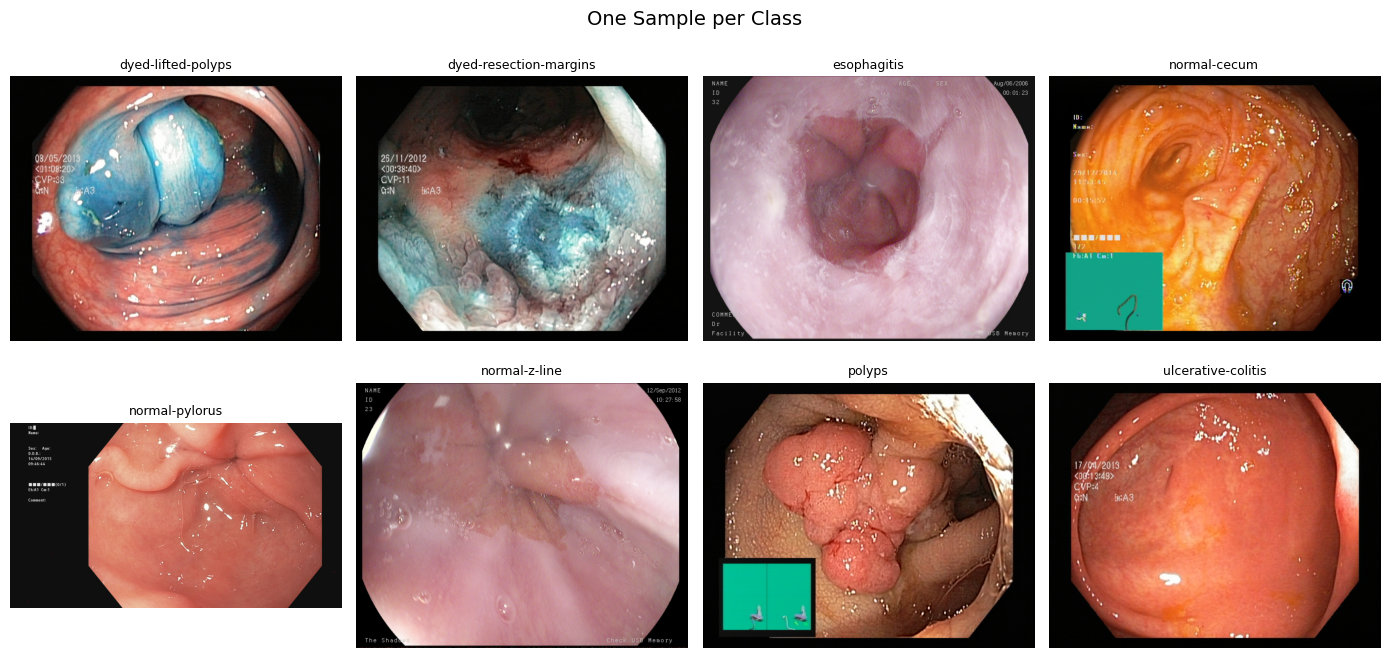

In [4]:
# ── One sample per class ──────────────────────────────────────────────────────
classes = sorted(os.listdir(TRAIN_DIR))
print("Classes:", classes)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, cls in zip(axes.ravel(), classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_path = os.path.join(cls_path, random.choice(os.listdir(cls_path)))
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(cls, fontsize=9)
    ax.axis('off')
plt.suptitle('One Sample per Class', fontsize=14)
plt.tight_layout()
plt.show()

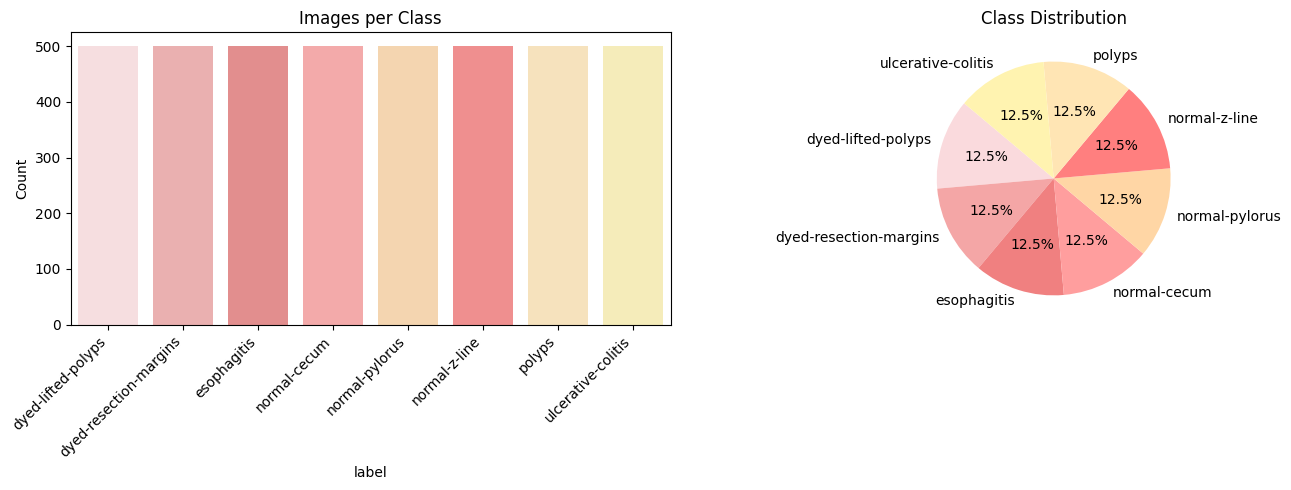

In [5]:
# ── Class distribution ────────────────────────────────────────────────────────
PASTEL = ["#FADADD","#F4A6A6","#F08080","#FF9E9E",
          "#FFD6A5","#FF7F7F","#FFE5B4","#FFF3B0"]

counts_df = pd.DataFrame(
    [(cls, len(os.listdir(os.path.join(TRAIN_DIR, cls)))) for cls in classes],
    columns=["label", "count"]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x="label", y="count", data=counts_df, palette=PASTEL, ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_title('Images per Class'); axes[0].set_ylabel('Count')

axes[1].pie(counts_df['count'], labels=counts_df['label'],
            autopct='%1.1f%%', startangle=140, colors=PASTEL)
axes[1].set_title('Class Distribution')
plt.tight_layout()
plt.show()

## 2. Build DataFrame & Splits

Split strategy (fixed seed = 42, consistent across all models):

```
All data (8000)
 ├── Test set      : 10%  (800)   ← held-out, never touched during training
 ├── Val set       : 10%  (800)   ← used for monitoring only
 └── Training pool : 80%  (6400)
       ├── Labeled   : 50% of pool (3200)  ← supervised training
       └── Unlabeled : 50% of pool (3200)  ← pseudo-label candidates
```

In [6]:
# ── Build master DataFrame ────────────────────────────────────────────────────
image_paths, class_names = [], []
for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    for img in os.listdir(cls_path):
        image_paths.append(os.path.join(cls_path, img))
        class_names.append(cls)

df_all = pd.DataFrame({'image_path': image_paths, 'label': class_names})
le = LabelEncoder()
# NOTE: label_num stored as str so flow_from_dataframe sparse mode works correctly
df_all['label_num'] = le.fit_transform(df_all['label']).astype(str)
CLASS_NAMES = list(le.classes_)
print(f"Total images: {len(df_all)}  |  Classes: {CLASS_NAMES}")

# ── Level 1: hold-out test set (10%) ─────────────────────────────────────────
pool_df, test_df = train_test_split(
    df_all, test_size=0.10, stratify=df_all['label_num'], random_state=42
)

# ── Level 2: validation set (~10% of total = 11.1% of pool) ──────────────────
pool_df, val_df = train_test_split(
    pool_df, test_size=0.111, stratify=pool_df['label_num'], random_state=42
)

# ── Level 3: 50/50 labeled / unlabeled split of remaining pool ───────────────
labeled_df, unlabeled_df = train_test_split(
    pool_df, train_size=0.50, stratify=pool_df['label_num'], random_state=42
)
labeled_df   = labeled_df.reset_index(drop=True)
unlabeled_df = unlabeled_df.reset_index(drop=True)

print(f"\nSplit summary:")
print(f"  Labeled   : {len(labeled_df):>5}")
print(f"  Unlabeled : {len(unlabeled_df):>5}")
print(f"  Val       : {len(val_df):>5}")
print(f"  Test      : {len(test_df):>5}")

Total images: 4000  |  Classes: ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']

Split summary:
  Labeled   :  1600
  Unlabeled :  1600
  Val       :   400
  Test      :   400


## 3. Utility Functions

In [7]:
# ── Generators ────────────────────────────────────────────────────────────────
def make_generators(train_df, val_df, test_df,
                    img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    """Return (train_gen, val_gen, test_gen)."""
    aug_gen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=25,
        width_shift_range=0.08,
        height_shift_range=0.08,
        zoom_range=0.15,
        shear_range=0.08,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.8, 1.2],
        channel_shift_range=10,
        fill_mode='nearest',
    )
    plain_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

    flow_kw = dict(
        x_col='image_path', y_col='label_num',
        target_size=img_size, class_mode='sparse',
        color_mode='rgb', batch_size=batch_size
    )
    tr = aug_gen.flow_from_dataframe(train_df,  shuffle=True,  **flow_kw)
    va = plain_gen.flow_from_dataframe(val_df,  shuffle=False, **flow_kw)  # FIX: shuffle=False
    te = plain_gen.flow_from_dataframe(test_df, shuffle=False, **flow_kw)  # FIX: shuffle=False
    return tr, va, te


def make_unlabeled_generator(unlabeled_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    """No-label generator for batched pseudo-label prediction."""
    plain_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
    return plain_gen.flow_from_dataframe(
        unlabeled_df,
        x_col='image_path', y_col=None,
        target_size=img_size, class_mode=None,
        color_mode='rgb', batch_size=batch_size, shuffle=False
    )

In [8]:
# ── LR Schedule & Compilation ─────────────────────────────────────────────────
def get_lr_schedule(steps_per_epoch, epochs, initial_lr=3e-4):
    """
    CosineDecay whose decay_steps = total training steps.
    This ensures the LR completes exactly one full decay cycle
    over the maximum possible training duration.
    FIX: was hardcoded to 1000, causing near-zero LR after epoch ~5.
    """
    return CosineDecay(
        initial_learning_rate=initial_lr,
        decay_steps=steps_per_epoch * epochs,
        alpha=1e-6
    )


def compile_model(model, steps_per_epoch, epochs, lr=3e-4):
    """
    Always recompile with a fresh CosineDecay schedule.
    Called once per training phase so decay_steps matches that phase's budget.
    NOTE: because the optimizer is built with a LearningRateSchedule,
    ReduceLROnPlateau is intentionally NOT used — it would raise TypeError.
    CosineDecay handles annealing automatically.
    """
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=get_lr_schedule(steps_per_epoch, epochs, lr)
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )


# ── Callbacks ────────────────────────────────────────────────────────────────
def ckpt_path(tag):
    return os.path.join(WORK_DIR, f'{MODEL_NAME}_{tag}_best.h5')


def get_callbacks(tag, monitor='val_accuracy'):
    """
    EarlyStopping + ModelCheckpoint.
    NOTE: ReduceLROnPlateau is intentionally excluded — incompatible with
    CosineDecay (LearningRateSchedule makes optimizer.lr non-settable).
    """
    return [
        EarlyStopping(
            monitor=monitor, patience=PATIENCE,
            restore_best_weights=True, verbose=1
        ),
        ModelCheckpoint(
            ckpt_path(tag), monitor=monitor,
            save_best_only=True, verbose=0
        ),
    ]


# ── Class weights ────────────────────────────────────────────────────────────
def get_class_weights(train_df):
    labels  = train_df['label_num'].values
    classes = np.unique(labels)
    weights = compute_class_weight('balanced', classes=classes, y=labels)
    return {int(c): w for c, w in zip(classes, weights)}

In [14]:
# ── Evaluation ───────────────────────────────────────────────────────────────
def evaluate_model(model, test_gen):
    import numpy as np

    test_gen.reset()

    y_true = np.asarray(test_gen.classes)
    y_prob = model.predict(test_gen, verbose=0)
    y_prob = np.asarray(y_prob)

    y_pred = np.argmax(y_prob, axis=1)

    loss, acc = model.evaluate(test_gen, verbose=0)

    report = classification_report(
        y_true, y_pred, target_names=CLASS_NAMES, output_dict=True
    )

    cm = confusion_matrix(y_true, y_pred)

    aucs = []
    for i in range(NUM_CLASSES):
        y_binary = np.asarray(y_true == i).astype(int)
        fpr, tpr, _ = roc_curve(y_binary, y_prob[:, i])
        aucs.append(auc(fpr, tpr))

    return {
        'loss': loss, 'accuracy': acc,
        'macro_auc': float(np.mean(aucs)),
        'macro_f1':  float(report['macro avg']['f1-score']),
        'report': report, 'cm': cm,
        'y_true': y_true, 'y_prob': y_prob,
    }
# def evaluate_model(model, test_gen):
#     test_gen.reset()
#     y_true = test_gen.classes
#     y_prob = model.predict(test_gen, verbose=0)
#     y_pred = np.argmax(y_prob, axis=1)
#     loss, acc = model.evaluate(test_gen, verbose=0)
#     report = classification_report(
#         y_true, y_pred, target_names=CLASS_NAMES, output_dict=True
#     )
#     cm = confusion_matrix(y_true, y_pred)
#     aucs = []
#     for i in range(NUM_CLASSES):
#         fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_prob[:, i])
#         aucs.append(auc(fpr, tpr))
#     return {
#         'loss': loss, 'accuracy': acc,
#         'macro_auc': float(np.mean(aucs)),
#         'macro_f1':  float(report['macro avg']['f1-score']),
#         'report': report, 'cm': cm,
#         'y_true': y_true, 'y_prob': y_prob,
#     }

In [10]:
# ── Plotting helpers ─────────────────────────────────────────────────────────
def plot_phase_history(histories, labels, title, save_path):
    """Plot concatenated training history across multiple phases."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    offset = 0
    colors = plt.cm.tab10(np.linspace(0, 0.6, len(histories)))
    for h, label, col in zip(histories, labels, colors):
        n = len(h.history['accuracy'])
        x = list(range(offset + 1, offset + n + 1))
        axes[0].plot(x, h.history['accuracy'],     color=col, label=f'{label} train')
        axes[0].plot(x, h.history['val_accuracy'], color=col, linestyle='--', label=f'{label} val')
        axes[1].plot(x, h.history['loss'],         color=col, label=f'{label} train')
        axes[1].plot(x, h.history['val_loss'],     color=col, linestyle='--', label=f'{label} val')
        if offset > 0:
            for ax in axes:
                ax.axvline(offset + 1, color='gray', linestyle=':', alpha=0.5)
        offset += n
    axes[0].set_title(f'{title} — Accuracy')
    axes[1].set_title(f'{title} — Loss')
    for ax in axes:
        ax.set_xlabel('Epoch'); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f'Saved → {save_path}')


def plot_ssl_progression(round_rows, title, save_path):
    fig, ax = plt.subplots(figsize=(7, 4))
    rounds = [r['round'] for r in round_rows]
    ax.plot(rounds, [r['test_acc']  for r in round_rows], marker='o', label='Test Acc')
    ax.plot(rounds, [r['macro_f1']  for r in round_rows], marker='s', label='Macro F1')
    ax.plot(rounds, [r['macro_auc'] for r in round_rows], marker='^', label='Macro AUC')
    ax.set_title(title); ax.set_xlabel('SSL Round')
    ax.set_xticks(rounds); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f'Saved → {save_path}')


def plot_confusion(cm, title, save_path):
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.4, linecolor='white')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right', fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f'Saved → {save_path}')


def plot_roc(y_true, y_prob, title, save_path):
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = plt.cm.tab10(np.linspace(0, 0.9, NUM_CLASSES))
    for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
        fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_prob[:, i])
        ax.plot(fpr, tpr, color=col, label=f'{cls} (AUC={auc(fpr, tpr):.2f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title, fontsize=12); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f'Saved → {save_path}')


def plot_confidence_distribution(y_probs, conf_thresh, save_path):
    confidence = np.max(y_probs, axis=1)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(confidence, bins=25, color='#F08080', edgecolor='white')
    ax.axvline(conf_thresh, color='navy', linestyle='--',
               label=f'Threshold={conf_thresh}')
    pct_accepted = 100 * np.mean(confidence >= conf_thresh)
    ax.set_title(f'Prediction Confidence Distribution  '
                 f'({pct_accepted:.1f}% ≥ {conf_thresh})')
    ax.set_xlabel('Confidence Score'); ax.set_ylabel('Number of Samples')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f'Saved → {save_path}')

## 4. Build MobileNet

In [11]:
def build_model(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)
    base   = MobileNet(weights='imagenet', include_top=False, input_tensor=inputs)

    # Phase-1: freeze all but last 20 layers
    for layer in base.layers[:-20]:
        layer.trainable = False
    for layer in base.layers[-20:]:
        layer.trainable = True

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs, name='MobileNet_SSL')


model = build_model()
print(f"Total params: {model.count_params():,}")
model.summary(line_length=90)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total params: 3,889,096


Model: "MobileNet_SSL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)              │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                        │ (None, 112, 112, 32)         │             864 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv1_bn (BatchNormalization)         │ (None, 112, 112, 32)         │             128 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv1_relu (ReLU)                     │ (None, 112, 112, 32)         │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_dw_1 (DepthwiseConv2D)           │ (None, 112, 112, 32)         │             288 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_dw_1_bn (BatchNormalization)     │ (None, 112, 112, 32)         │             128 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_dw_1_relu (ReLU)                 │ (None, 112, 112, 32)         │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_pw_1 (Conv2D)                    │ (None, 112, 112, 64)         │           2,048 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_pw_1_bn (BatchNormalization)     │ (None, 112, 112, 64)         │             256 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_pw_1_relu (ReLU)                 │ (None, 112, 112, 64)         │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_pad_2 (ZeroPadding2D)            │ (None, 113, 113, 64)         │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_dw_2 (DepthwiseConv2D)           │ (None, 56, 56, 64)           │             576 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_dw_2_bn (BatchNormalization)     │ (None, 56, 56, 64)           │             256 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_dw_2_relu (ReLU)                 │ (None, 56, 56, 64)           │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_pw_2 (Conv2D)                    │ (None, 56, 56, 128)          │           8,192 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_pw_2_bn (BatchNormalization)     │ (None, 56, 56, 128)          │             512 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_pw_2_relu (ReLU)                 │ (None, 56, 56, 128)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_dw_3 (DepthwiseConv2D)           │ (None, 56, 56, 128)          │           1,152 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_dw_3_bn (BatchNormalization)     │ (None, 56, 56, 128)          │             512 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_dw_3_relu (ReLU)                 │ (None, 56, 56, 128)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv_pw_3 (Conv2D)                    │ (None, 56, 56, 128)          │          16,38

 Total params: 3,889,096 (14.84 MB)

 Trainable params: 2,521,864 (9.62 MB)

 Non-trainable params: 1,367,232 (5.22 MB)

## 5. Supervised Warm-Up (Phase 1 + Phase 2)

The model must be competent **before** pseudo-labeling begins.  
Without warm-up, early SSL rounds would generate mostly wrong pseudo-labels that corrupt the model.

- **Phase 1** — only the classification head is trained (backbone frozen, lr = 3e-4)
- **Phase 2** — all layers unfrozen, full fine-tune at lower lr (5e-5)

In [12]:
# Build generators for the labeled split
train_gen, val_gen, test_gen = make_generators(labeled_df, val_df, test_df)
cw = get_class_weights(labeled_df)

# ── Phase 1: head only ────────────────────────────────────────────────────────
print(f"Phase 1 — head training  (lr=3e-4, max {EPOCHS_WARMUP_P1} epochs)")
compile_model(model, len(train_gen), EPOCHS_WARMUP_P1, lr=3e-4)
h_p1 = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_WARMUP_P1, class_weight=cw,
    callbacks=get_callbacks('warmup_p1'), verbose=1
)

# ── Phase 2: full fine-tune ───────────────────────────────────────────────────
print(f"\nPhase 2 — full fine-tune (lr=5e-5, max {EPOCHS_WARMUP_P2} epochs)")
for layer in model.layers:
    layer.trainable = True
compile_model(model, len(train_gen), EPOCHS_WARMUP_P2, lr=5e-5)  # fresh schedule
h_p2 = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_WARMUP_P2, class_weight=cw,
    callbacks=get_callbacks('warmup_p2'), verbose=1
)

print("\nWarm-up complete.")

Found 1600 validated image filenames belonging to 8 classes.
Found 400 validated image filenames belonging to 8 classes.
Found 400 validated image filenames belonging to 8 classes.
Phase 1 — head training  (lr=3e-4, max 20 epochs)
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - accuracy: 0.3758 - loss: 2.1584 

50/50 ━━━━━━━━━━━━━━━━━━━━ 1583s 31s/step - accuracy: 0.5369 - loss: 1.4839 - val_accuracy: 0.3450 - val_loss: 2.5142
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.7346 - loss: 0.7267

50/50 ━━━━━━━━━━━━━━━━━━━━ 46s 913ms/step - accuracy: 0.7444 - loss: 0.6843 - val_accuracy: 0.6300 - val_loss: 1.3034
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.8248 - loss: 0.4712

50/50 ━━━━━━━━━━━━━━━━━━━━ 46s 917ms/step - accuracy: 0.8163 - loss: 0.5264 - val_accuracy: 0.7150 - val_loss: 0.9192
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step - accuracy: 0.8461 - loss: 0.4347

50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 890ms/step - accuracy: 0.8519 - loss: 0.4241 - val_accuracy: 0.8125 - val_loss: 0.6237
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.8730 - loss: 0.3479

50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 913ms/step - accuracy: 0.8669 - loss: 0.3452 - val_accuracy: 0.8725 - val_loss: 0.4194
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 875ms/step - accuracy: 0.8706 - loss: 0.3346 - val_accuracy: 0.8525 - val_loss: 0.4362
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 854ms/step - accuracy: 0.9050 - loss: 0.2753 - val_accuracy: 0.8575 - val_loss: 0.4154
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.9027 - loss: 0.2676

50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 908ms/step - accuracy: 0.8963 - loss: 0.2920 - val_accuracy: 0.8900 - val_loss: 0.3717
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 869ms/step - accuracy: 0.9094 - loss: 0.2469 - val_accuracy: 0.8900 - val_loss: 0.3426
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.9178 - loss: 0.2302

50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 891ms/step - accuracy: 0.9094 - loss: 0.2519 - val_accuracy: 0.9000 - val_loss: 0.3344
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 873ms/step - accuracy: 0.9212 - loss: 0.1841 - val_accuracy: 0.8950 - val_loss: 0.3102
Epoch 12/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 857ms/step - accuracy: 0.9362 - loss: 0.2045 - val_accuracy: 0.8800 - val_loss: 0.3170
Epoch 13/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 869ms/step - accuracy: 0.9312 - loss: 0.1842 - val_accuracy: 0.8950 - val_loss: 0.3154
Epoch 14/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 862ms/step - accuracy: 0.9388 - loss: 0.1669 - val_accuracy: 0.8950 - val_loss: 0.3011
Epoch 15/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 859ms/step - accuracy: 0.9362 - loss: 0.1647 - val_accuracy: 0.8950 - val_loss: 0.3100
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 10.

Phase 2 — full fine-tune (lr=5e-5, max 15 epochs)
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 743ms/step - accuracy: 0.8881 - loss: 0.3030

50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 986ms/step - accuracy: 0.8813 - loss: 0.3137 - val_accuracy: 0.9025 - val_loss: 0.3199
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 880ms/step - accuracy: 0.9081 - loss: 0.2542 - val_accuracy: 0.8875 - val_loss: 0.3036
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 876ms/step - accuracy: 0.9062 - loss: 0.2690 - val_accuracy: 0.8850 - val_loss: 0.3140
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 882ms/step - accuracy: 0.9206 - loss: 0.2142 - val_accuracy: 0.8925 - val_loss: 0.2949
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 868ms/step - accuracy: 0.9294 - loss: 0.1958 - val_accuracy: 0.8975 - val_loss: 0.2891
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 869ms/step - accuracy: 0.9294 - loss: 0.1984 - val_accuracy: 0.8850 - val_loss: 0.2984
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.

Warm-up complete.


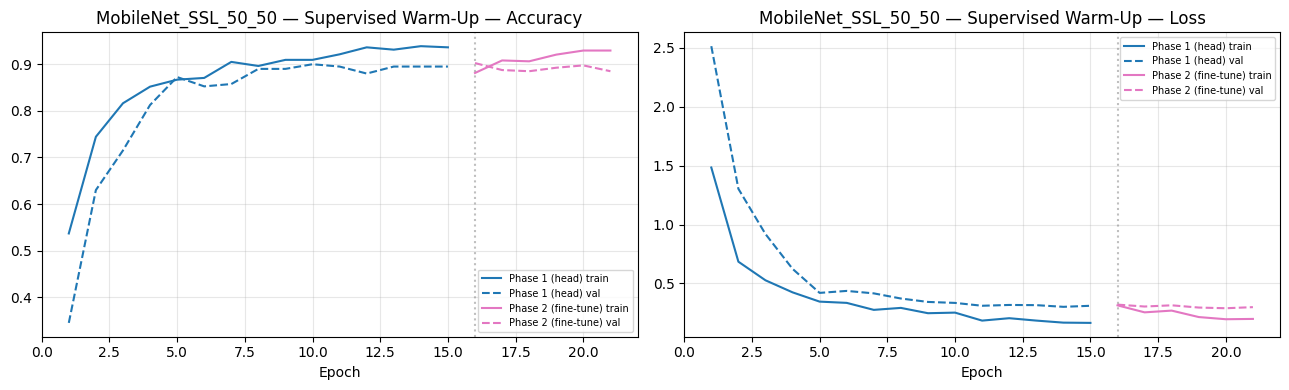

Saved → /content/drive/MyDrive/Kvasir-SEG(Classification)/kvasir-dataset/MobileNet_SSL_50_50_warmup_curves.png

Warm-up test results:
  acc=0.8975  f1=0.8959  auc=0.9910


In [15]:
# Plot warm-up training curves
plot_phase_history(
    [h_p1, h_p2],
    ['Phase 1 (head)', 'Phase 2 (fine-tune)'],
    title=f'{MODEL_NAME} — Supervised Warm-Up',
    save_path=os.path.join(WORK_DIR, f'{MODEL_NAME}_warmup_curves.png')
)

# Warm-up evaluation
warmup_metrics = evaluate_model(model, test_gen)
print(f"\nWarm-up test results:")
print(f"  acc={warmup_metrics['accuracy']:.4f}  "
      f"f1={warmup_metrics['macro_f1']:.4f}  "
      f"auc={warmup_metrics['macro_auc']:.4f}")

## 6. Semi-Supervised Self-Training (SSL Rounds)

Each round:
1. **Batch-predict** the entire unlabeled pool in one call (fast)
2. Accept samples with `confidence ≥ CONF_THRESH` as pseudo-labeled
3. Remove accepted samples from the unlabeled pool (no re-use)
4. **Train on combined labeled + pseudo-labeled data** (labeled data anchors training)
5. Evaluate on test set and record metrics

**Key design decisions:**
- Pseudo-labels are concatenated *with* the real labeled set — not trained separately first
- A fresh `CosineDecay` schedule is created per round so LR is correctly calibrated
- `EarlyStopping` saves the best checkpoint of each round

In [16]:
def generate_pseudo_labels(model, unlabeled_df, conf_thresh=CONF_THRESH):
    """
    Batch-predict the entire unlabeled pool in one pass.
    FIX: replaces the original row-by-row loop (3200 individual predict calls).
    Returns a DataFrame of accepted pseudo-labeled samples.
    """
    gen = make_unlabeled_generator(unlabeled_df)
    gen.reset()
    # Predict all at once — fast, uses GPU batching
    probs      = model.predict(gen, verbose=1)[:len(unlabeled_df)]
    confidence = np.max(probs, axis=1)
    pseudo_lbl = np.argmax(probs, axis=1).astype(str)

    mask = confidence >= conf_thresh
    pseudo_df = unlabeled_df.copy().reset_index(drop=True)
    pseudo_df['label_num'] = pseudo_lbl
    pseudo_df  = pseudo_df[mask].copy()

    print(f"    Pseudo-labeled: {mask.sum()}/{len(unlabeled_df)} "
          f"({mask.mean()*100:.1f}%)  conf≥{conf_thresh}")
    return pseudo_df

In [ ]:
current_labeled   = labeled_df.copy()
current_unlabeled = unlabeled_df.copy()
ssl_round_rows    = []
ssl_histories     = []

for rnd in range(SSL_ROUNDS):
    print(f"\n{'='*62}")
    print(f"  SSL Round {rnd+1}/{SSL_ROUNDS}  "
          f"labeled={len(current_labeled)}  unlabeled={len(current_unlabeled)}")
    print(f"{'='*62}")

    # ── Step 1: pseudo-label the unlabeled pool ───────────────────────────────
    if len(current_unlabeled) > 0:
        pseudo_df = generate_pseudo_labels(model, current_unlabeled)
        accepted_paths = set(pseudo_df['image_path'])
        # Remove accepted samples from unlabeled pool
        current_unlabeled = current_unlabeled[
            ~current_unlabeled['image_path'].isin(accepted_paths)
        ].copy().reset_index(drop=True)
    else:
        pseudo_df = pd.DataFrame(columns=current_labeled.columns)
        print("    Unlabeled pool exhausted.")

    # ── Step 2: combine labeled + pseudo-labeled ──────────────────────────────
    # FIX: labeled data is always included — pseudo-labels supplement, not replace.
    # This prevents catastrophic forgetting of real supervision signal.
    if len(pseudo_df) > 0:
        combined_df = pd.concat([current_labeled, pseudo_df], ignore_index=True)
    else:
        combined_df = current_labeled.copy()
        print("    No pseudo-labels accepted this round — training on labeled only.")

    # ── Step 3: train on combined set ────────────────────────────────────────
    # FIX: single model.fit() call — no separate pseudo/labeled training steps.
    # History is aligned: one train_loss and one val_loss per epoch.
    tr_gen, va_gen, te_gen = make_generators(combined_df, val_df, test_df)
    cw = get_class_weights(combined_df)
    compile_model(model, len(tr_gen), EPOCHS_SSL, lr=1e-4)  # FIX: decay_steps calibrated to this phase

    hist = model.fit(
        tr_gen, validation_data=va_gen,
        epochs=EPOCHS_SSL, class_weight=cw,
        callbacks=get_callbacks(f'ssl_r{rnd+1}'),
        verbose=1
    )
    ssl_histories.append(hist)

    # ── Step 4: evaluate ─────────────────────────────────────────────────────
    best_val = max(hist.history['val_accuracy'])
    metrics  = evaluate_model(model, te_gen)
    print(f"  Round {rnd+1} → val_acc={best_val:.4f}  "
          f"test_acc={metrics['accuracy']:.4f}  "
          f"f1={metrics['macro_f1']:.4f}  "
          f"auc={metrics['macro_auc']:.4f}")

    ssl_round_rows.append({
        'round':        rnd + 1,
        'labeled_size': len(current_labeled),
        'combined_size':len(combined_df),
        'pseudo_added': len(pseudo_df),
        'unlabeled_remaining': len(current_unlabeled),
        'val_acc':   best_val,
        'test_acc':  metrics['accuracy'],
        'macro_f1':  metrics['macro_f1'],
        'macro_auc': metrics['macro_auc'],
    })

    # Grow the labeled pool for next round
    if len(pseudo_df) > 0:
        current_labeled = pd.concat(
            [current_labeled, pseudo_df], ignore_index=True
        )

print("\nSSL training complete.")


  SSL Round 1/3  labeled=1600  unlabeled=1600
Found 1600 validated image filenames.
50/50 ━━━━━━━━━━━━━━━━━━━━ 1229s 25s/step
    Pseudo-labeled: 1309/1600 (81.8%)  conf≥0.9
Found 2909 validated image filenames belonging to 8 classes.
Found 400 validated image filenames belonging to 8 classes.
Found 400 validated image filenames belonging to 8 classes.
Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9098 - loss: 0.2636

91/91 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9141 - loss: 0.2571 - val_accuracy: 0.8975 - val_loss: 0.3388
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 78s 859ms/step - accuracy: 0.9261 - loss: 0.2159 - val_accuracy: 0.8800 - val_loss: 0.3550
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 81s 852ms/step - accuracy: 0.9381 - loss: 0.1810 - val_accuracy: 0.8750 - val_loss: 0.3642
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.9380 - loss: 0.1630

91/91 ━━━━━━━━━━━━━━━━━━━━ 80s 883ms/step - accuracy: 0.9409 - loss: 0.1683 - val_accuracy: 0.9000 - val_loss: 0.2980
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 808ms/step - accuracy: 0.9506 - loss: 0.1478

91/91 ━━━━━━━━━━━━━━━━━━━━ 81s 886ms/step - accuracy: 0.9546 - loss: 0.1245 - val_accuracy: 0.9025 - val_loss: 0.3258
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.9476 - loss: 0.1391

91/91 ━━━━━━━━━━━━━━━━━━━━ 79s 871ms/step - accuracy: 0.9484 - loss: 0.1449 - val_accuracy: 0.9100 - val_loss: 0.3020
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 797ms/step - accuracy: 0.9652 - loss: 0.1142

...

95/95 ━━━━━━━━━━━━━━━━━━━━ 82s 863ms/step - accuracy: 0.9637 - loss: 0.0956 - val_accuracy: 0.9150 - val_loss: 0.3319
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.9713 - loss: 0.0868

95/95 ━━━━━━━━━━━━━━━━━━━━ 85s 886ms/step - accuracy: 0.9693 - loss: 0.0918 - val_accuracy: 0.9200 - val_loss: 0.3319
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 81s 845ms/step - accuracy: 0.9690 - loss: 0.0862 - val_accuracy: 0.9150 - val_loss: 0.3269
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 79s 832ms/step - accuracy: 0.9713 - loss: 0.0821 - val_accuracy: 0.9150 - val_loss: 0.3166
Epoch 9/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 78s 821ms/step - accuracy: 0.9750 - loss: 0.0739 - val_accuracy: 0.9150 - val_loss: 0.3204
Epoch 10/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 81s 854ms/step - accuracy: 0.9700 - loss: 0.0805 - val_accuracy: 0.9125 - val_loss: 0.3200
Restoring model weights from the end of the best epoch: 6.
  Round 2 → val_acc=0.9200  test_acc=0.9100  f1=0.9085  auc=0.9911

  SSL Round 3/3  labeled=3034  unlabeled=166
Found 166 validated image filenames.
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step
    Pseudo-labeled: 60/166 (36.1%)  conf≥0.9
Found 3094 validated image filenames belonging to 8 classes.
Found 400 val

97/97 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9544 - loss: 0.1495 - val_accuracy: 0.9025 - val_loss: 0.4048
Epoch 2/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.9714 - loss: 0.0890

97/97 ━━━━━━━━━━━━━━━━━━━━ 83s 860ms/step - accuracy: 0.9641 - loss: 0.1034 - val_accuracy: 0.9125 - val_loss: 0.3262
Epoch 3/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 82s 845ms/step - accuracy: 0.9632 - loss: 0.1016 - val_accuracy: 0.9125 - val_loss: 0.3363
Epoch 4/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.9629 - loss: 0.0956

97/97 ━━━━━━━━━━━━━━━━━━━━ 82s 845ms/step - accuracy: 0.9612 - loss: 0.0987 - val_accuracy: 0.9175 - val_loss: 0.3064
Epoch 5/10
55/97 ━━━━━━━━━━━━━━━━━━━━ 33s 789ms/step - accuracy: 0.9772 - loss: 0.0660

training curve for SSL

In [ ]:
current_labeled   = labeled_df.copy()
current_unlabeled = unlabeled_df.copy()
ssl_round_rows    = []
ssl_histories     = []

for rnd in range(SSL_ROUNDS):
    print(f"\n{'='*62}")
    print(f"  SSL Round {rnd+1}/{SSL_ROUNDS}  "
          f"labeled={len(current_labeled)}  unlabeled={len(current_unlabeled)}")
    print(f"{'='*62}")

    # ── Step 1: pseudo-label the unlabeled pool ───────────────────────────────
    if len(current_unlabeled) > 0:
        pseudo_df = generate_pseudo_labels(model, current_unlabeled)
        accepted_paths = set(pseudo_df['image_path'])
        # Remove accepted samples from unlabeled pool
        current_unlabeled = current_unlabeled[
            ~current_unlabeled['image_path'].isin(accepted_paths)
        ].copy().reset_index(drop=True)
    else:
        pseudo_df = pd.DataFrame(columns=current_labeled.columns)
        print("    Unlabeled pool exhausted.")

    # ── Step 2: combine labeled + pseudo-labeled ──────────────────────────────
    # FIX: labeled data is always included — pseudo-labels supplement, not replace.
    # This prevents catastrophic forgetting of real supervision signal.
    if len(pseudo_df) > 0:
        combined_df = pd.concat([current_labeled, pseudo_df], ignore_index=True)
    else:
        combined_df = current_labeled.copy()
        print("    No pseudo-labels accepted this round — training on labeled only.")

    # ── Step 3: train on combined set ────────────────────────────────────────
    # FIX: single model.fit() call — no separate pseudo/labeled training steps.
    # History is aligned: one train_loss and one val_loss per epoch.
    tr_gen, va_gen, te_gen = make_generators(combined_df, val_df, test_df)
    cw = get_class_weights(combined_df)
    compile_model(model, len(tr_gen), EPOCHS_SSL, lr=1e-4)  # FIX: decay_steps calibrated to this phase

    hist = model.fit(
        tr_gen, validation_data=va_gen,
        epochs=EPOCHS_SSL, class_weight=cw,
        callbacks=get_callbacks(f'ssl_r{rnd+1}'),
        verbose=1
    )
    ssl_histories.append(hist)

    # ── Step 4: evaluate ─────────────────────────────────────────────────────
    best_val = max(hist.history['val_accuracy'])
    metrics  = evaluate_model(model, te_gen)
    print(f"  Round {rnd+1} → val_acc={best_val:.4f}  "
          f"test_acc={metrics['accuracy']:.4f}  "
          f"f1={metrics['macro_f1']:.4f}  "
          f"auc={metrics['macro_auc']:.4f}")

    ssl_round_rows.append({
        'round':        rnd + 1,
        'labeled_size': len(current_labeled),
        'combined_size':len(combined_df),
        'pseudo_added': len(pseudo_df),
        'unlabeled_remaining': len(current_unlabeled),
        'val_acc':   best_val,
        'test_acc':  metrics['accuracy'],
        'macro_f1':  metrics['macro_f1'],
        'macro_auc': metrics['macro_auc'],
    })

    # Grow the labeled pool for next round
    if len(pseudo_df) > 0:
        current_labeled = pd.concat(
            [current_labeled, pseudo_df], ignore_index=True
        )

print("\nSSL training complete.")

# ── SSL per-round training curves ─────────────────────────────────────────────
plot_phase_history(
    ssl_histories,
    [f'Round {i+1}' for i in range(len(ssl_histories))],
    title=f'{MODEL_NAME} — SSL Training Curves',
    save_path=os.path.join(WORK_DIR, f'{MODEL_NAME}_ssl_curves.png')
)

## 7. Final Evaluation

In [ ]:
# Final evaluation with a fresh generator (avoids stale generator state)
_, _, final_te_gen = make_generators(current_labeled, val_df, test_df)
final_metrics = evaluate_model(model, final_te_gen)

print("\n" + "="*50)
print("  FINAL TEST RESULTS")
print("="*50)
print(f"  Accuracy  : {final_metrics['accuracy']:.4f}")
print(f"  Macro F1  : {final_metrics['macro_f1']:.4f}")
print(f"  Macro AUC : {final_metrics['macro_auc']:.4f}")
print(f"  Test Loss : {final_metrics['loss']:.4f}")
print()
print(classification_report(
    final_metrics['y_true'],
    np.argmax(final_metrics['y_prob'], axis=1),
    target_names=CLASS_NAMES
))

## 8. Visualisations

In [ ]:
# ── SSL round progression ─────────────────────────────────────────────────────
plot_ssl_progression(
    ssl_round_rows,
    title=f'{MODEL_NAME} — SSL Round Progression',
    save_path=os.path.join(WORK_DIR, f'{MODEL_NAME}_ssl_progression.png')
)

In [ ]:
# ── SSL per-round training curves ─────────────────────────────────────────────
plot_phase_history(
    ssl_histories,
    [f'Round {i+1}' for i in range(len(ssl_histories))],
    title=f'{MODEL_NAME} — SSL Training Curves',
    save_path=os.path.join(WORK_DIR, f'{MODEL_NAME}_ssl_curves.png')
)

In [ ]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
plot_confusion(
    final_metrics['cm'],
    title=f'{MODEL_NAME} — Confusion Matrix',
    save_path=os.path.join(WORK_DIR, f'{MODEL_NAME}_cm.png')
)

In [ ]:
# ── ROC curves ───────────────────────────────────────────────────────────────
plot_roc(
    final_metrics['y_true'],
    final_metrics['y_prob'],
    title=f'{MODEL_NAME} — ROC Curves',
    save_path=os.path.join(WORK_DIR, f'{MODEL_NAME}_roc.png')
)

In [ ]:
# ── Prediction confidence distribution on test set ────────────────────────────
plot_confidence_distribution(
    final_metrics['y_prob'],
    conf_thresh=CONF_THRESH,
    save_path=os.path.join(WORK_DIR, f'{MODEL_NAME}_confidence.png')
)

## 9. Save Results

In [ ]:
# ── SSL round summary table ───────────────────────────────────────────────────
ssl_df = pd.DataFrame(ssl_round_rows)
print("SSL Round Summary:")
print(ssl_df[['round','labeled_size','combined_size','pseudo_added',
              'val_acc','test_acc','macro_f1','macro_auc']].round(4).to_string(index=False))

# ── Final results row ─────────────────────────────────────────────────────────
results = pd.DataFrame([{
    'model':       MODEL_NAME,
    'regime':      '50/50',
    'labeled':     len(labeled_df),
    'unlabeled':   len(unlabeled_df),
    'ssl_rounds':  SSL_ROUNDS,
    'test_acc':    final_metrics['accuracy'],
    'macro_f1':    final_metrics['macro_f1'],
    'macro_auc':   final_metrics['macro_auc'],
    'test_loss':   final_metrics['loss'],
}])

results_path = os.path.join(WORK_DIR, f'{MODEL_NAME}_results.csv')
ssl_path     = os.path.join(WORK_DIR, f'{MODEL_NAME}_ssl_history.csv')
results.to_csv(results_path, index=False)
ssl_df.to_csv(ssl_path, index=False)
print(f"\nSaved results → {results_path}")
print(f"Saved SSL history → {ssl_path}")
print(results[['model','regime','test_acc','macro_f1','macro_auc']].round(4).to_string(index=False))

# ── Save final model weights ──────────────────────────────────────────────────
final_weights = os.path.join(WORK_DIR, f'{MODEL_NAME}_final.h5')
model.save(final_weights)
print(f"\nModel saved → {final_weights}")

del model
keras.backend.clear_session()
gc.collect()
print("Memory cleared.")